<a href="https://colab.research.google.com/github/lourdesmaria-mvg/Practicas_procesos/blob/main/Copia_de_GPs_PRADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio: simular y visualizar GPs

El objetivo es aprender a simular trayectorias de un GP, usando algunas de las herramientas más habituales de _machine learning_ (las que hemos visto: Python, Numpy, matplotlib). Como resultado final, generaremos las imágenes vistas en las diapositivas.

**Nota:** Si escribís sobre este notebook que os comparto, vuestros cambios no se guardarán (porque solo tenéis permisos de lectura). Igual que con el PAS, tendréis que crear una copia vuestra ("Archivo > Guardar una copia en Drive").

In [4]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Muestras de una normal multivariante / multidimensional

Puesto que simular trayectorias de un GP involucra simular de una normal multivariante, veamos primero cómo hacer esto.

En la siguiente celda se deben obtener 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Para ello, utiliza la función `np.random.multivariate_normal` (busca en internet cómo usarla).

Además, visualiza el resultado obtenido, así como su shape.

In [5]:
# COMPLETAR!

vector_medias = np.zeros(3)
matriz_covarianzas = np.eye(3)
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, size=num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 1.30776077 -0.54539118 -0.33547887]
 [-1.2564919  -0.06985839  0.84765004]
 [-0.20160917  1.13901894 -0.03996322]
 [ 0.02462307  0.47392946  1.79895596]
 [-0.55344207 -0.20897577  0.11739053]
 [ 0.08481733  1.28486189  1.29620231]
 [ 1.16868712  1.06038115  0.29734721]
 [ 2.19527765 -2.57600734  0.14985564]
 [-1.06036217 -0.07308857  0.08973809]
 [ 1.49947528  0.67036268  1.04732858]
 [-0.03717677  0.32583579  1.72539594]
 [ 0.47496597 -0.01589793  0.16795811]
 [ 0.96137761 -0.31242879 -0.14877741]
 [-0.58269785  0.43366906 -0.72006117]
 [ 0.39822927 -0.60676457 -0.88413683]
 [-0.64858221 -0.63269034  0.00690119]
 [ 0.50024916  1.15153691 -0.43373303]
 [ 0.21831056  0.32036091 -0.31350316]
 [-2.1713437  -0.17443533  1.34010488]
 [-0.13174405 -1.2789321   0.96720619]
 [-0.9305538   1.09459413  0.25002574]
 [-0.15964382  1.22972548  1.58830076]
 [ 0.40332223  0.50644237 -0.74169569]
 [-1.33477037  0.01624906  1.39894511]
 [-1.68898937  0.49770927 -0.03377231

Haz ahora lo mismo pero para una normal con matriz de covarianzas que no sea la identidad, sino por ejemplo $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

Puedes simplificar algo el código si usas la función `np.diag` para crear la matriz diagonal.

¿Qué diferencias esperarías ver en las muestras obtenidas?


In [6]:
# COMPLETAR!

vector_medias = np.zeros(3)
matriz_covarianzas = np.diag([1, 10, 100])
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, size=num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[-4.08766139e-01 -1.62643969e+00 -2.12234232e+01]
 [-7.24467489e-01 -5.93387659e-01 -8.71385816e-01]
 [-4.41845728e-01 -2.55768636e-01  3.92610660e+00]
 [-1.06081378e+00 -2.13132854e+00 -1.47716599e+01]
 [-4.16785994e-02  3.57676240e-01  1.13645322e+01]
 [-3.45700913e-01  2.35563470e+00  5.97928556e-01]
 [ 6.72154220e-01 -2.05112884e+00 -3.06323530e+00]
 [-9.62165790e-01  1.22454725e+00 -3.76668653e+00]
 [ 6.06920505e-01 -2.98842061e+00  1.37610694e+00]
 [-1.35973165e+00  1.46841969e+00  2.21441525e+01]
 [-4.97435905e-01  3.89860968e+00  1.08573432e+01]
 [ 1.27044246e+00  3.82894263e+00  4.69856661e+00]
 [ 6.29529293e-01 -7.98218394e+00  2.15179786e+00]
 [-1.52684048e-01  7.31805252e+00 -6.47973240e+00]
 [-7.77660990e-02  2.62122364e+00  8.71981162e-01]
 [ 2.19812533e-01 -2.26033336e+00 -1.11104191e+01]
 [ 2.07143670e-01  1.63588716e+00  5.82095830e+00]
 [-5.94586687e-01 -3.04037358e+00 -8.39779416e+00]
 [-1.04565052e+00  1.12248190e+00  3.20127793e+00]
 [-3

## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permita simular de un GP con kernel RBF. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

En el punto 5 se explicará la manera más limpia de usar otras funciones de medias. También se comentará la manera más adecuada para pasar el kernel como argumento de la función. Es decir, de modo que no sea necesario definir `simular_GP_RBF`, sino simplemente `simular_GP` (y que el kernel se pase como argumento de la función). Todo ello necesita del concepto de _clases_, algo que (creo) no se estudia en el grado en matemáticas.

Definimos la función principal:

In [7]:
# COMPLETAR

def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
  """
  Simular un GP con kernel RBF.

  Input:
  t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
  sigma_sq: varianza del kernel. Float.
  lengthscale: parámetro de escala del kernel. Float.
  num_samples: número de muestras a generar. Int.

  Output:
  samples: muestras del GP. Numpy array de shape (num_samples, n)

  """

  # Paso 1: calcula el vector de medias. No uses bucles for, puedes usar np.zeros_like
  vector_medias = np.zeros_like(t)

  # Paso 2: calcula la matriz de covarianzas. No uses bucles for, utiliza la vectorización de numpy y en particular la idea de broadcasting que se comentó en la intro a numpy.
  distancias_cuadrado = (t[:, None] - t[None, :])**2 #Puedo usar también t.reshape(1,n), t.reshape(n,1).
  matriz_covs = sigma_sq * np.exp(-distancias_cuadrado / (2 * lengthscale**2))

  # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal
  jitter = 1e-8 * np.eye(len(t))
  samples = np.random.multivariate_normal(vector_medias, matriz_covs + jitter, size=num_samples)

  return samples

Ahora utilizamos esta función para generar imágenes similares a las de las diapositivas 59 y 62.

Para ello, genera las trayectorias con la función recién definida, `simular_GP_RBF`, y píntalas con `plt.plot`

Opcional: si quieres tener diferentes ejes (subplots) en la misma figura, como se hace en las diapositivas 59 y 62, puedes mirar cómo usar `plt.subplots`.

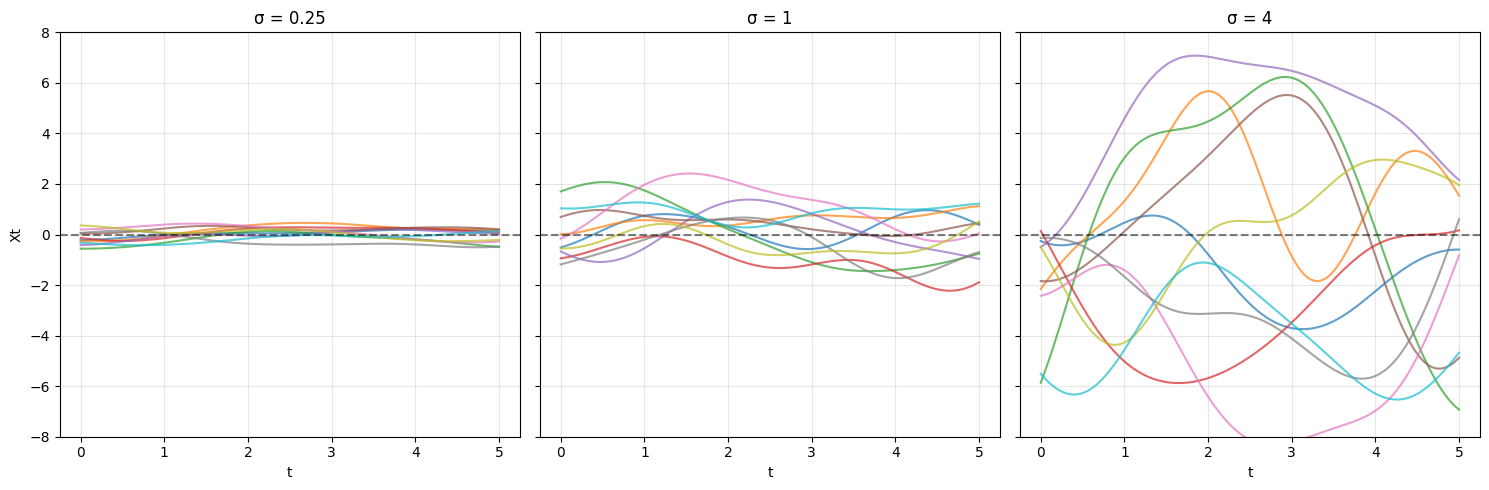

In [ ]:
# COMPLETAR (PARA LA DIAPOSITIVA 59)

# Para generar el grid, mira la función np.linspace

#Configuramos los parámetros
t = np.linspace(0, 5, 200)
lengthscale = 1.0
sigmas = [0.25, 1, 4]
n_trayectorias = 10

#Generamos la figura
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, sigma in enumerate(sigmas):
    #Generamos las trayectorias
    muestras = simular_GP_RBF(t, sigma_sq=sigma**2, lengthscale=lengthscale, num_samples=n_trayectorias)

    #Representamos en el subplot correspondiente
    ax = axes[i]
    for j in range(n_trayectorias):
        ax.plot(t, muestras[j, :], lw=1.5, alpha=0.7)

    #Estética del gráfico
    ax.set_title(f'σ = {sigma}')
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('t')
    ax.grid(True, alpha=0.3)
    if i == 0: ax.set_ylabel('Xt')

plt.ylim(-8, 8)
plt.tight_layout()
plt.show()

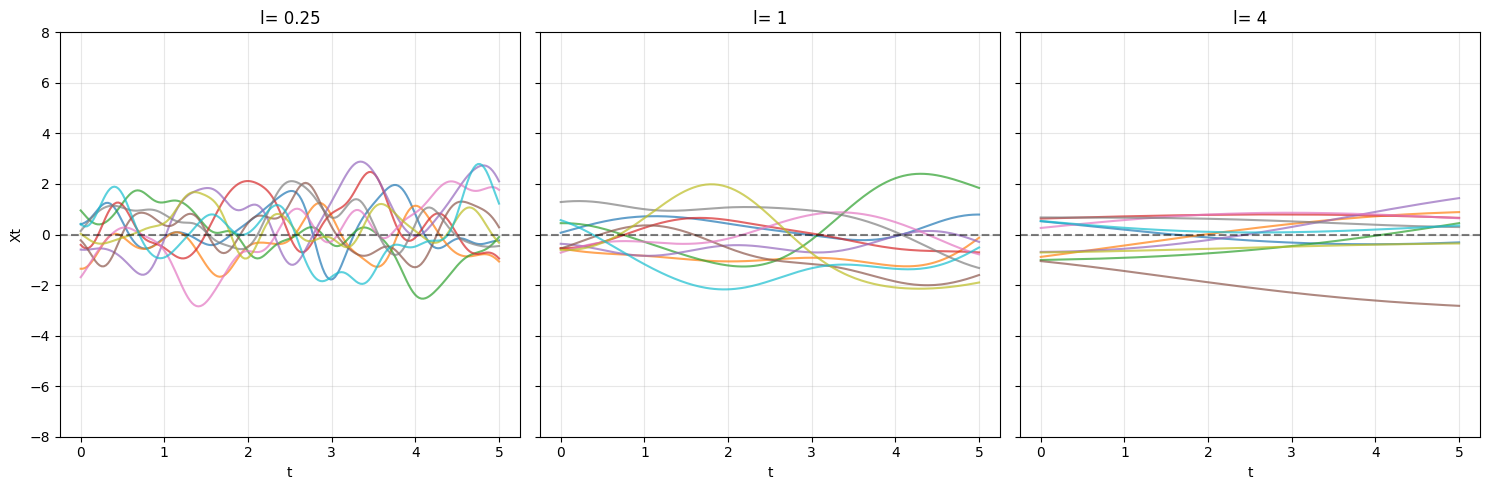

In [ ]:
# COMPLETAR (PARA LA DIAPOSITIVA 62)

# Para generar el grid, mira la función np.linspace

#Configuramos los parámetros
t = np.linspace(0, 5, 200)
lengthscale = [0.25, 1, 4]
sigmas = 1.0
n_trayectorias = 10

#Generamos la figura
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, sigma in enumerate(lengthscale):
    #Generamos las trayectorias
    muestras = simular_GP_RBF(t, sigma_sq=sigmas**2, lengthscale=sigma, num_samples=n_trayectorias)

    #Representamos en el subplot correspondiente
    ax = axes[i]
    for j in range(n_trayectorias):
        ax.plot(t, muestras[j, :], lw=1.5, alpha=0.7)

    #Estética del gráfico
    ax.set_title(f'l= {sigma}')
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('t')
    ax.grid(True, alpha=0.3)
    if i == 0: ax.set_ylabel('Xt')

plt.ylim(-8, 8)
plt.tight_layout()
plt.show()

## 3. Simular un GP con kernel periódico

En esta sección vamos a definir una función `simular_GP_periodic` que nos permita simular de un GP con kernel periódico. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [ ]:
def simular_GP_periodic(t, sigma_sq=1, lengthscale=1, period=1, num_samples=1):
    #Calculamos el vector de medias
    vector_medias = np.zeros_like(t)

    #Hacemos la matriz de covarianzas usando broadcasting para las distancias
    distancias = np.abs(t[:, None] - t[None, :])

    #Aplicamos la fórmula del kernel periódico
    arg_seno = np.pi * distancias / period
    matriz_covs = sigma_sq * np.exp(-2 * (np.sin(arg_seno)**2) / (lengthscale**2))

    #Obtenemos las muestras
    jitter = 1e-8 * np.eye(len(t))
    samples = np.random.multivariate_normal(vector_medias, matriz_covs + jitter, size=num_samples)

    return samples

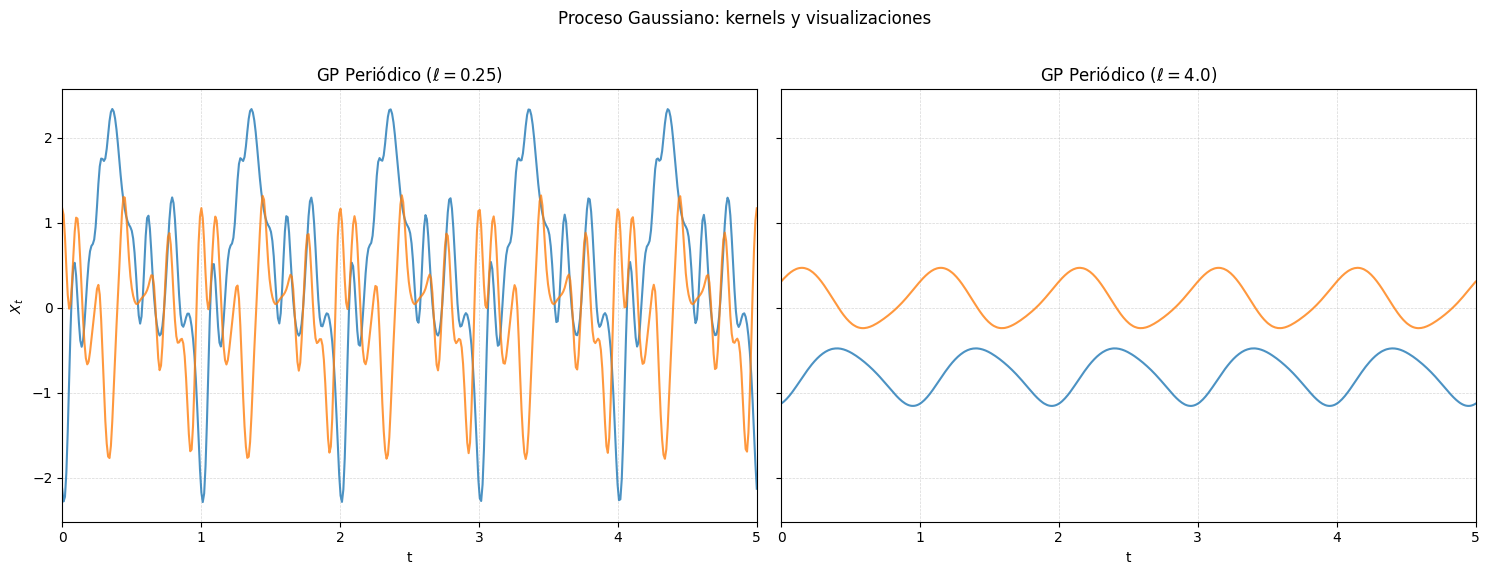

In [ ]:
# COMPLETAR (PARA LA DIAPOSITIVA 72)

t_per = np.linspace(0, 5, 500)
n_samples = 2

#Escribimos los parámetros que son fijos
p_fijo = 1.0
sigma_sq_fija = 1.0**2

#Definimos los lengthscales a probar
lengthscales = [0.25, 4.0]

#Creamos los subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharey=True)

for i, l_val in enumerate(lengthscales):
    ax = axes[i]

    #Generamos las muestras con la función anterior
    muestras = simular_GP_periodic(t_per, sigma_sq=sigma_sq_fija, lengthscale=l_val, period=p_fijo, num_samples=n_samples)

    #Graficamos
    for j in range(n_samples):
        ax.plot(t_per, muestras[j, :], lw=1.5, alpha=0.8)

    ax.set_title(f'GP Periódico ($\\ell = {l_val}$)')
    ax.set_xlabel('t')
    ax.set_xticks([0, 1, 2, 3, 4, 5])
    ax.set_xlim([0, 5])
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

    if i == 0:
        ax.set_ylabel('$X_t$')

# Título general (opcional)
fig.suptitle('Proceso Gaussiano: kernels y visualizaciones', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

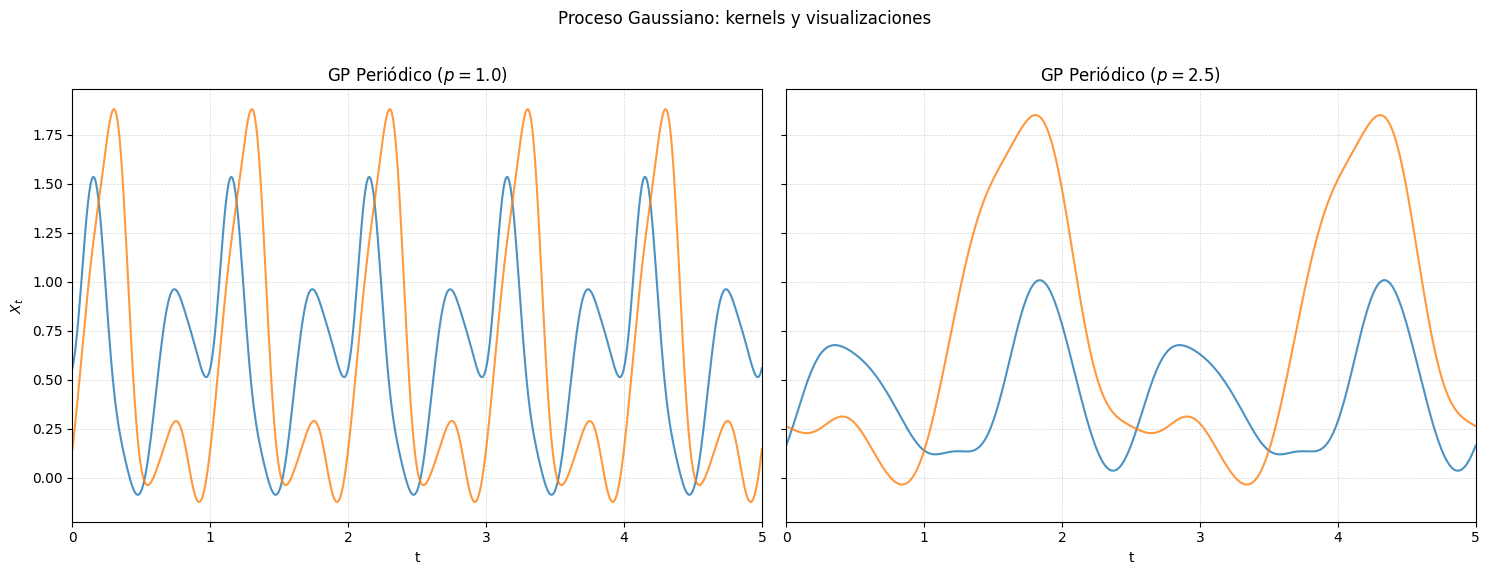

In [ ]:
# COMPLETAR (PARA LA DIAPOSITIVA 74)

t_per = np.linspace(0, 5, 500)
n_samples = 2

#Escribimos los parámetros que son fijos
l_fijo = 1.0
sigma_sq_fija = 1.0**2

#Definimos la lista de periodos a probar
periodos = [1.0, 2.5]

#Creamos los subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharey=True)

for i, p_val in enumerate(periodos):
    ax = axes[i]

    #Generamos las muestras con la función definida antes
    muestras = simular_GP_periodic(t_per, sigma_sq=sigma_sq_fija, lengthscale=l_fijo, period=p_val, num_samples=n_samples)

    for j in range(n_samples):
        ax.plot(t_per, muestras[j, :], lw=1.5, alpha=0.8)

    ax.set_title(f'GP Periódico ($p = {p_val}$)')
    ax.set_xlabel('t')
    ax.set_xticks([0, 1, 2, 3, 4, 5])
    ax.set_xlim([0, 5])
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

    if i == 0:
        ax.set_ylabel('$X_t$')

fig.suptitle('Proceso Gaussiano: kernels y visualizaciones', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

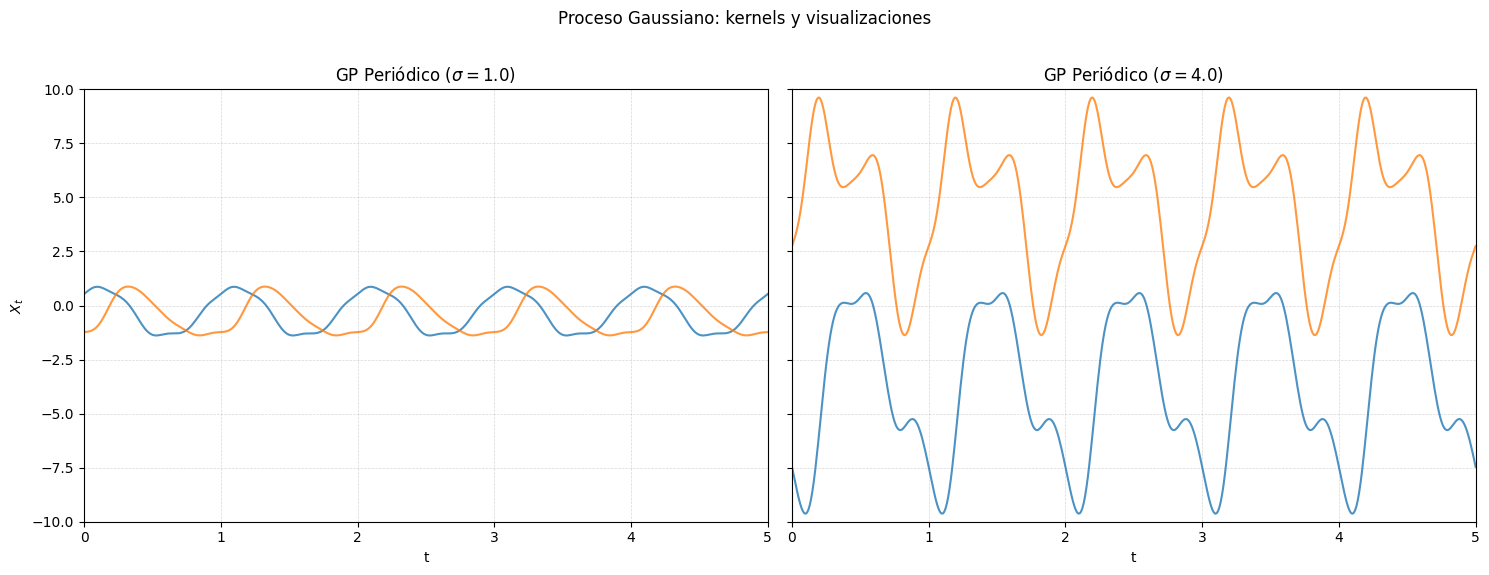

In [ ]:
# COMPLETAR (PARA LA DIAPOSITIVA 76)

t_per = np.linspace(0, 5, 500)
n_samples = 2

#Definimos los parámetros que están fijos
l_fijo = 1.0
p_fijo = 1.0

#Definimos la lista de desviaciones estándar a probar
sigmas = [1.0, 4.0]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharey=True)

for i, sigma_val in enumerate(sigmas):
    ax = axes[i]

    #Calculamos sigma^2
    sigma_cuadrado = sigma_val**2

    #Generamos las muestras con la función definida anteriormente
    muestras = simular_GP_periodic(t_per, sigma_sq=sigma_cuadrado, lengthscale=l_fijo, period=p_fijo, num_samples=n_samples)

    for j in range(n_samples):
        ax.plot(t_per, muestras[j, :], lw=1.5, alpha=0.8)

    ax.set_title(f'GP Periódico ($\\sigma = {sigma_val}$)')
    ax.set_xlabel('t')
    ax.set_xticks([0, 1, 2, 3, 4, 5])
    ax.set_xlim([0, 5])
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

    if i == 0:
        ax.set_ylabel('$X_t$')

    ax.set_ylim([-10, 10])

fig.suptitle('Proceso Gaussiano: kernels y visualizaciones', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## 4. Simular un GP con kernel DPK (concretamente, polinómico hasta grado $m$)

En esta sección vamos a definir una función `simular_GP_DPKpoly` que nos permita simular de un GP con kernel DPK. Concretamente, un kernel DPK con funciones base $1$, $t$, $\dots$, $t^m$. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [8]:
def simular_GP_DPKpoly(t, sigma_sq=1, degree=1, num_samples=1):

  #Creamos el vector de medias
  vector_medias = np.zeros_like(t)

  #Creamos la matriz de covarianzas usando broadcasting para el producto escalar
  producto_escalar = t[:, None] * t[None, :]

  #Aplicamos la fórmula: sigma_sq * (1 + t_i * t_j)^degree
  matriz_covs = sigma_sq * (1 + producto_escalar)**degree

  #Obtenermos las muestras
  jitter = 1e-8 * np.eye(len(t))
  samples = np.random.multivariate_normal(vector_medias, matriz_covs + jitter, size=num_samples)

  return samples

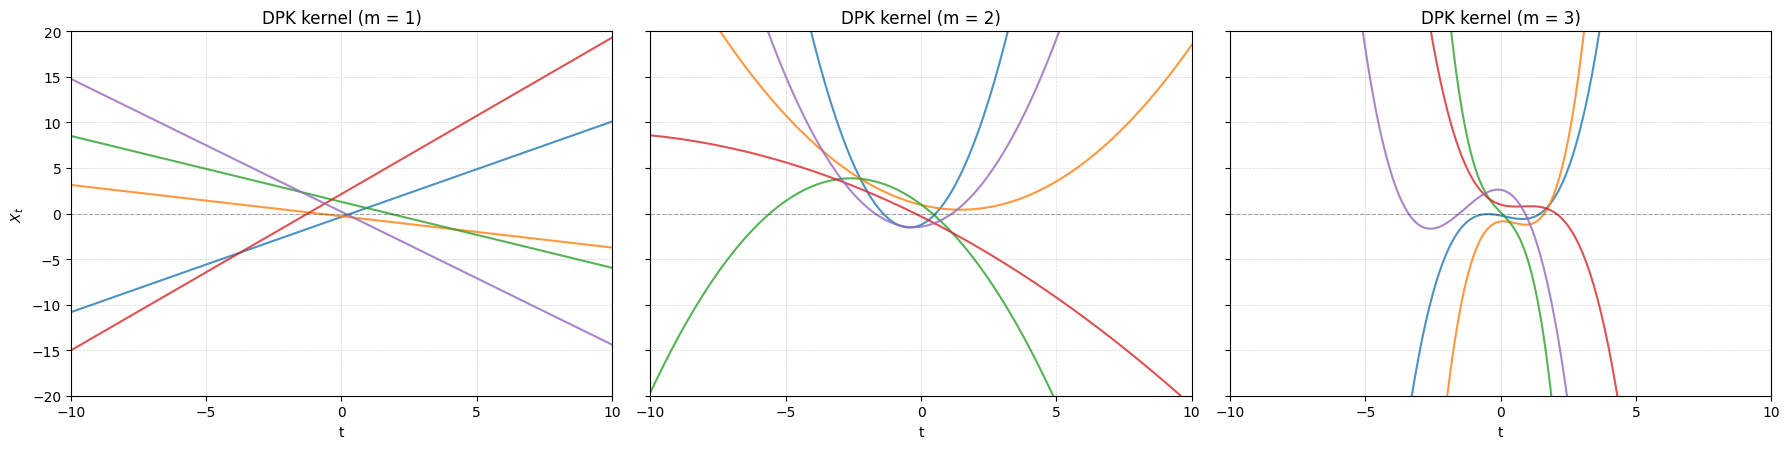

In [9]:
#DIAPOSITIVA 89

t_dpk = np.linspace(-10, 10, 300)

#Definimos un parámetro sigma fjo
sigma_sq_dpk = 1.0

grados_m = [1, 2, 3]

#Definimos el número de trayectorias a dibujar por gráfico:
n_trayectorias_dpk = 5

#Creamos una figura con 1 fila y 3 columnas
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), sharey=True)


for i, m_val in enumerate(grados_m):
    ax = axes[i]

    #Generamos las trayectorias usando la función simular_GP_DPKpoly
    trayectorias = simular_GP_DPKpoly(t=t_dpk, sigma_sq=sigma_sq_dpk, degree=m_val, num_samples=n_trayectorias_dpk)

    #Dibujamos las trayectorias
    for j in range(n_trayectorias_dpk):
        ax.plot(t_dpk, trayectorias[j, :], alpha=0.8, lw=1.5)

    ax.set_title(f'DPK kernel (m = {m_val})')
    ax.set_xlabel('t')

    if i == 0:
        ax.set_ylabel('$X_t$')

    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.3)

    ax.set_xlim([-10, 10])
    ax.set_ylim([-20, 20])

    ax.set_xticks([-10, -5, 0, 5, 10])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 5. Opcional: ¿Cómo hacer que el kernel se pase como parámetro? ¿y la función de medias?